# Part 1: PCA Implementation Using NumPy


In [1]:
import numpy as np

# Generate a dummy dataset
X = np.random.randint(10, 50, 100).reshape(20, 5)

print("Original Shape:", X.shape)

# Step 1: Mean Centering
X_meaned = X - np.mean(X, axis=0)

# Step 2: Covariance Matrix
cov_mat = np.cov(X_meaned, rowvar=False)

# Step 3: Eigen Values and Eigen Vectors
eigen_values, eigen_vectors = np.linalg.eigh(cov_mat)

# Step 4: Sort Eigen Values in Descending Order
sorted_index = np.argsort(eigen_values)[::-1]

sorted_eigenvalue = eigen_values[sorted_index]
sorted_eigenvectors = eigen_vectors[:, sorted_index]

# Step 5: Select Principal Components
n_components = 2

eigenvector_subset = sorted_eigenvectors[:, 0:n_components]

# Step 6: Transform Data
X_reduced = np.dot(
    eigenvector_subset.transpose(),
    X_meaned.transpose()
).transpose()

print("Reduced Shape:", X_reduced.shape)

print("\nReduced Dataset:")
print(X_reduced)

Original Shape: (20, 5)
Reduced Shape: (20, 2)

Reduced Dataset:
[[ 12.05303706 -22.45576876]
 [ -0.92678116  -7.71017346]
 [ -5.92952496  23.66440416]
 [ 12.08551534   4.53146771]
 [ -8.28228724 -21.44014956]
 [-13.69524674  -7.89919309]
 [-17.4168616   10.59273129]
 [ 21.6308359    5.51266451]
 [ 16.74513175  10.49077476]
 [  0.75882974   0.52028582]
 [ -1.10755675  -2.36151963]
 [ -9.32784576  11.46417054]
 [ -6.26202173  -6.40299409]
 [ 24.51362468  -0.15933962]
 [-11.70334262 -14.49952451]
 [  0.6652898    0.78021712]
 [  9.90922312   0.87631787]
 [-18.80919741  -2.36519111]
 [  9.21203211   1.50910757]
 [-14.11285354  15.35171247]]


# Part 2: PCA on Iris Dataset

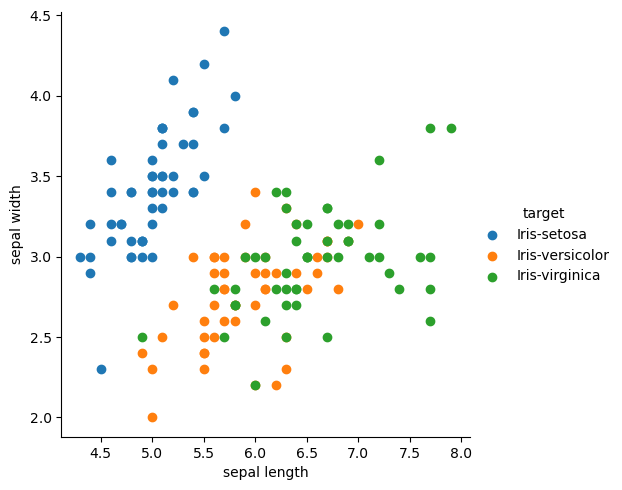

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np

# Load Iris Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

data = pd.read_csv(
    url,
    names=[
        'sepal length',
        'sepal width',
        'petal length',
        'petal width',
        'target'
    ]
)

# Features
x = data.iloc[:, 0:4]

# Target
target = data.iloc[:, 4]

# Visualize Original Data
sb.FacetGrid(data, hue='target', height=5) \
    .map(plt.scatter, "sepal length", "sepal width") \
    .add_legend()

plt.show()

# Create PCA Function

In [3]:
def PCA(X, num_components):

    # Step 1: Mean Centering
    X_meaned = X - np.mean(X, axis=0)

    # Step 2: Covariance Matrix
    cov_mat = np.cov(X_meaned, rowvar=False)

    # Step 3: Eigen Values and Eigen Vectors
    eigen_values, eigen_vectors = np.linalg.eigh(cov_mat)

    # Step 4: Sort Eigen Values
    sorted_index = np.argsort(eigen_values)[::-1]

    sorted_eigenvalue = eigen_values[sorted_index]
    sorted_eigenvectors = eigen_vectors[:, sorted_index]

    # Step 5: Select Principal Components
    eigenvector_subset = sorted_eigenvectors[:, 0:num_components]

    # Step 6: Transform Data
    X_reduced = np.dot(
        eigenvector_subset.transpose(),
        X_meaned.transpose()
    ).transpose()

    return X_reduced

# Apply PCA

In [4]:
mat_reduced = PCA(x, 2)

print(mat_reduced.shape)
print(mat_reduced[:5])

(150, 2)
[[ 2.68420713  0.32660731]
 [ 2.71539062 -0.16955685]
 [ 2.88981954 -0.13734561]
 [ 2.7464372  -0.31112432]
 [ 2.72859298  0.33392456]]


# Create Reduced DataFrame

In [5]:
principal_df = pd.DataFrame(
    mat_reduced,
    columns=['PC1', 'PC2']
)

principal_df = pd.concat(
    [principal_df, pd.DataFrame(target)],
    axis=1
)

print(principal_df.head())

        PC1       PC2       target
0  2.684207  0.326607  Iris-setosa
1  2.715391 -0.169557  Iris-setosa
2  2.889820 -0.137346  Iris-setosa
3  2.746437 -0.311124  Iris-setosa
4  2.728593  0.333925  Iris-setosa


# Visualize PCA Result

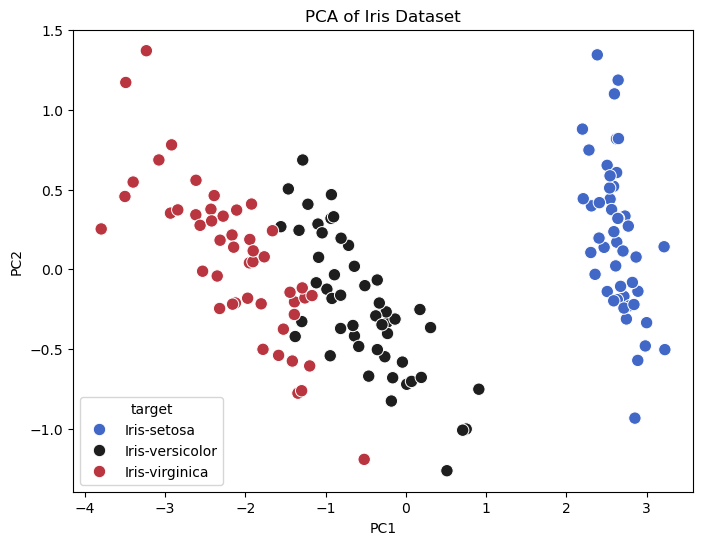

In [6]:
plt.figure(figsize=(8, 6))

sb.scatterplot(
    data=principal_df,
    x='PC1',
    y='PC2',
    hue='target',
    s=80,
    palette='icefire'
)

plt.title("PCA of Iris Dataset")
plt.show()